# Выборочные распределения

## Модуль 3: Закон больших чисел и Центральная предельная теорема

В этом ноутбуке мы рассмотрим два фундаментальных закона теории вероятностей, которые являются основой статистического вывода.

### Содержание:
1. Выборочные распределения
2. Закон больших чисел (ЗБЧ)
3. Центральная предельная теорема (ЦПТ)
4. Стандартная ошибка
5. Практические применения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Выборочные распределения

**Выборочное распределение** — это распределение статистики (например, выборочного среднего) при многократном извлечении выборок из генеральной совокупности.

### Выборочное среднее
Если $X_1, X_2, ..., X_n$ — случайная выборка из распределения с $E[X] = \mu$ и $\text{Var}(X) = \sigma^2$, то:

$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i$$

**Свойства выборочного среднего:**
- $E[\bar{X}_n] = \mu$ (несмещённость)
- $\text{Var}(\bar{X}_n) = \frac{\sigma^2}{n}$
- $\sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}}$ (стандартная ошибка)

Генеральная совокупность:
  μ = 1.9919
  σ = 1.9859


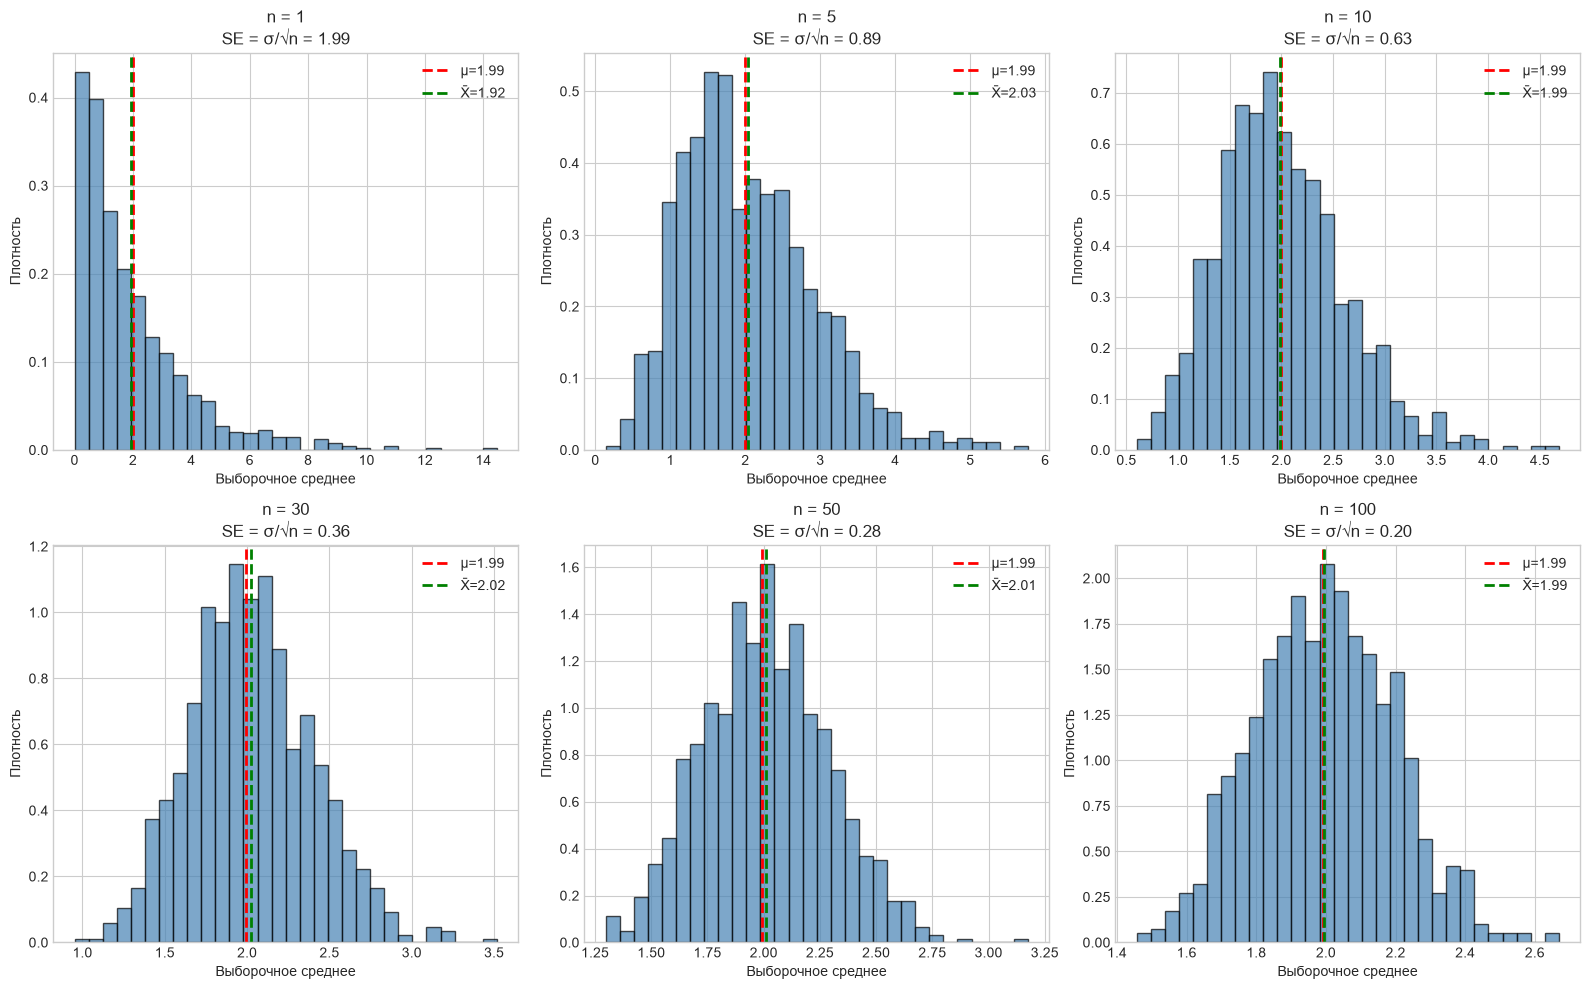


Стандартная ошибка для разных размеров выборки:
n =   1: SE = 1.9859
n =   5: SE = 0.8881
n =  10: SE = 0.6280
n =  30: SE = 0.3626
n =  50: SE = 0.2809
n = 100: SE = 0.1986


In [2]:
# Демонстрация выборочного распределения
np.random.seed(42)

# Генеральная совокупность (экспоненциальное распределение)
population = np.random.exponential(scale=2, size=100000)
mu = np.mean(population)
sigma = np.std(population)

print(f'Генеральная совокупность:')
print(f'  μ = {mu:.4f}')
print(f'  σ = {sigma:.4f}')

# Извлечение выборок разного размера
sample_sizes = [1, 5, 10, 30, 50, 100]
n_experiments = 1000

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    # Извлечение n_experiments выборок размера n
    sample_means = []
    for _ in range(n_experiments):
        sample = np.random.choice(population, size=n, replace=True)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    
    # Визуализация
    axes[idx].hist(sample_means, bins=30, density=True, alpha=0.7, 
                   color='steelblue', edgecolor='black')
    axes[idx].axvline(mu, color='red', linestyle='--', linewidth=2, label=f'μ={mu:.2f}')
    axes[idx].axvline(np.mean(sample_means), color='green', linestyle='--', 
                      linewidth=2, label=f'X̄={np.mean(sample_means):.2f}')
    axes[idx].set_xlabel('Выборочное среднее')
    axes[idx].set_ylabel('Плотность')
    axes[idx].set_title(f'n = {n}\nSE = σ/√n = {sigma/np.sqrt(n):.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print('\nСтандартная ошибка для разных размеров выборки:')
print('=' * 40)
for n in sample_sizes:
    se = sigma / np.sqrt(n)
    print(f'n = {n:>3}: SE = {se:.4f}')

## 2. Закон больших чисел (ЗБЧ)

**Закон больших чисел** утверждает, что выборочное среднее стремится к математическому ожиданию при увеличении размера выборки.

### Слабая форма (Закон Бернулли):
Для любого $\varepsilon > 0$:
$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| > \varepsilon) = 0$$

### Сильная форма (Закон Колмогорова):
$$P\left(\lim_{n \to \infty} \bar{X}_n = \mu\right) = 1$$

**Интуитивно:** Чем больше выборка, тем ближе выборочное среднее к истинному среднему.

**Применения:**
- Страхование: средние выплаты стабилизируются
- Казино: преимущество казино проявляется в долгосрочной перспективе
- A/B тесты: чем больше样本, тем точнее оценка

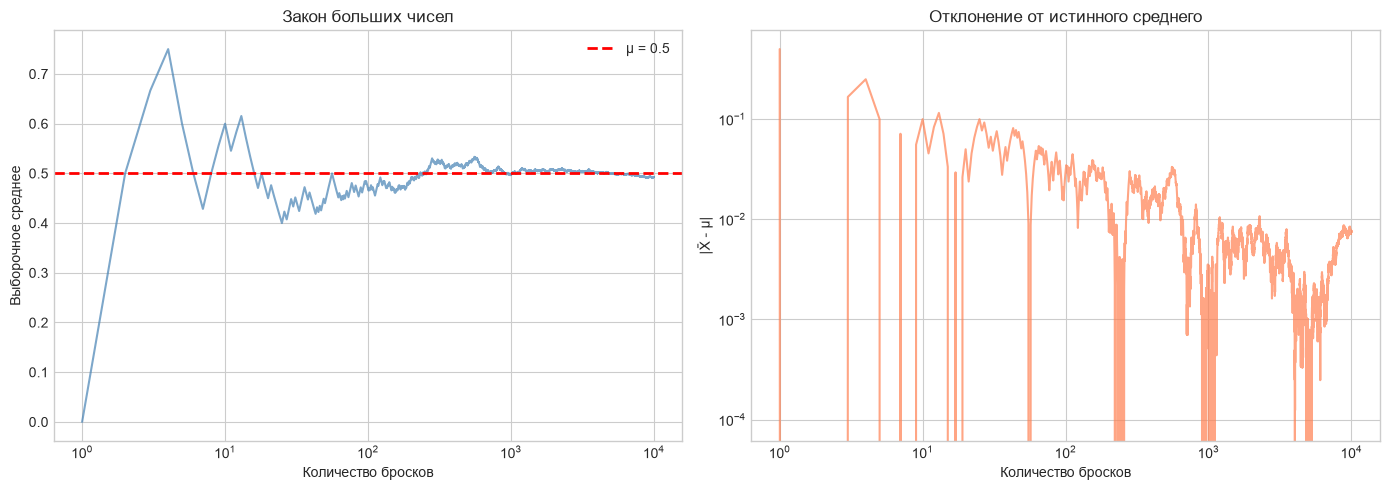

Сходимость выборочного среднего к μ


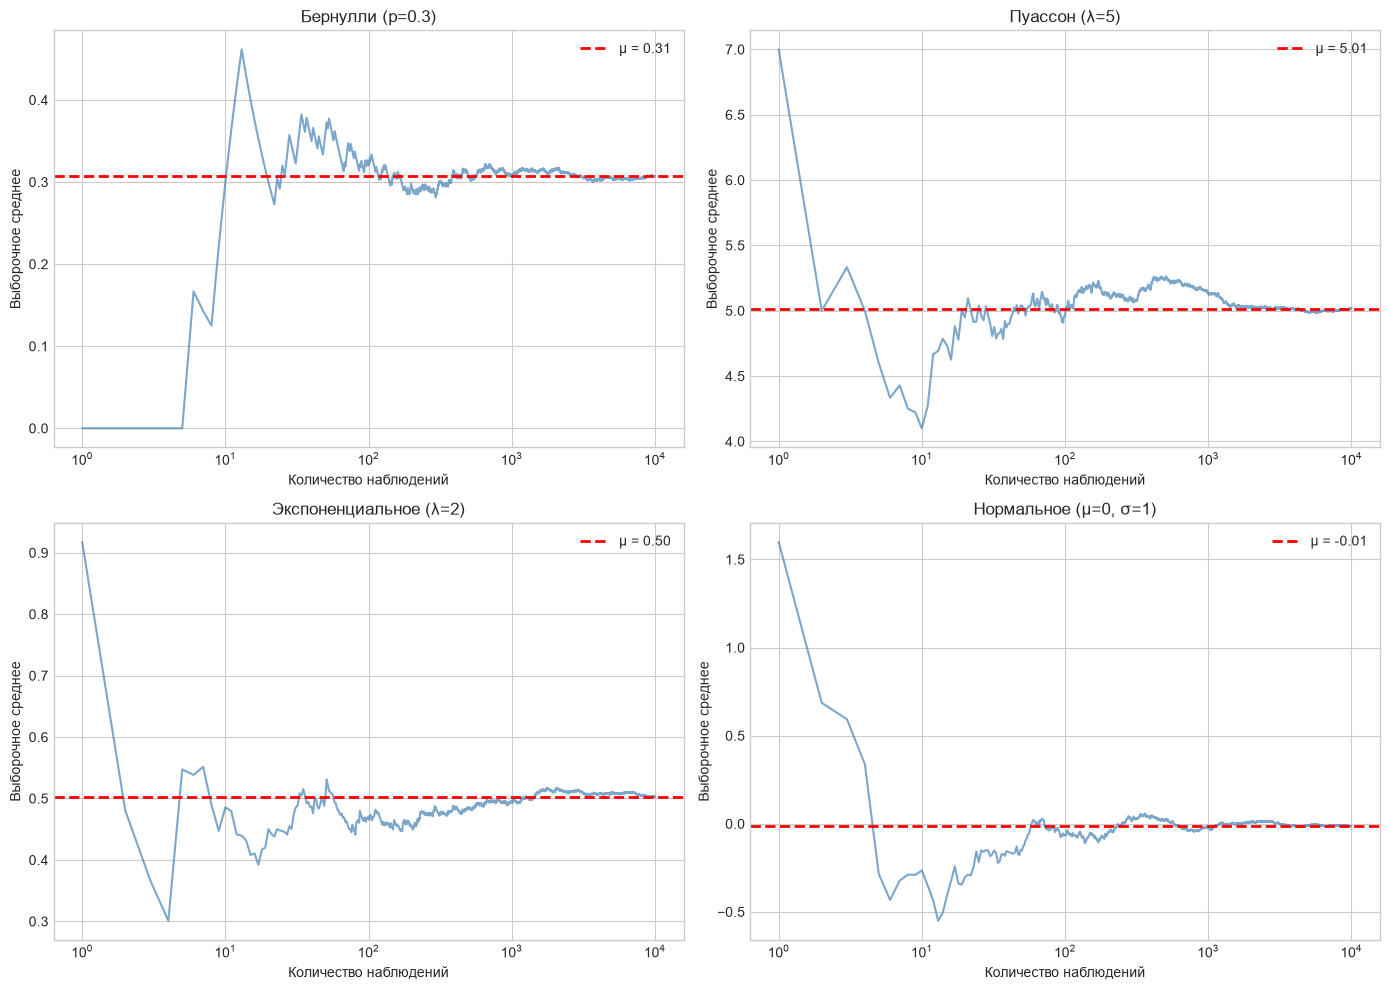

In [3]:
# Демонстрация Закона больших чисел
np.random.seed(42)

# Параметры генеральной совокупности
mu_true = 0.5  # Вероятность успеха (монета смещенная)
n_max = 10000

# Генерация последовательности бросков
coin_flips = np.random.binomial(1, mu_true, n_max)

# Кумулятивное среднее
cumulative_mean = np.cumsum(coin_flips) / np.arange(1, n_max + 1)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кумулятивное среднее
axes[0].plot(range(1, n_max + 1), cumulative_mean, color='steelblue', alpha=0.7)
axes[0].axhline(y=mu_true, color='red', linestyle='--', linewidth=2, label=f'μ = {mu_true}')
axes[0].set_xlabel('Количество бросков')
axes[0].set_ylabel('Выборочное среднее')
axes[0].set_title('Закон больших чисел')
axes[0].legend()
axes[0].set_xscale('log')

# Отклонение от истинного среднего
deviation = np.abs(cumulative_mean - mu_true)
axes[1].plot(range(1, n_max + 1), deviation, color='coral', alpha=0.7)
axes[1].set_xlabel('Количество бросков')
axes[1].set_ylabel('|X̄ - μ|')
axes[1].set_title('Отклонение от истинного среднего')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Демонстрация на разных распределениях
print('Сходимость выборочного среднего к μ')
print('=' * 50)

distributions = {
    'Бернулли (p=0.3)': np.random.binomial(1, 0.3, n_max),
    'Пуассон (λ=5)': np.random.poisson(5, n_max),
    'Экспоненциальное (λ=2)': np.random.exponential(0.5, n_max),
    'Нормальное (μ=0, σ=1)': np.random.normal(0, 1, n_max)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, data) in enumerate(distributions.items()):
    ax = axes[idx // 2, idx % 2]
    cumulative_mean = np.cumsum(data) / np.arange(1, n_max + 1)
    true_mean = np.mean(data)  # Используем истинное среднее
    
    ax.plot(range(1, n_max + 1), cumulative_mean, color='steelblue', alpha=0.7)
    ax.axhline(y=true_mean, color='red', linestyle='--', linewidth=2, 
               label=f'μ = {true_mean:.2f}')
    ax.set_xlabel('Количество наблюдений')
    ax.set_ylabel('Выборочное среднее')
    ax.set_title(name)
    ax.legend()
    ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 3. Центральная предельная теорема (ЦПТ)

**Центральная предельная теорема** — одна из самых важных теорем в статистике.

### Формулировка:
Если $X_1, X_2, ..., X_n$ — случайная выборка из распределения с $E[X] = \mu$ и $\text{Var}(X) = \sigma^2 < \infty$, то при $n \to \infty$:

$$\frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} N(0, 1)$$

или эквивалентно:

$$\bar{X}_n \xrightarrow{d} N\left(\mu, \frac{\sigma^2}{n}\right)$$

### Почему это важно?
1. Выборочное среднее имеет (приблизительно) нормальное распределение
2. Это работает для ЛЮБОГО исходного распределения!
3. Это основа для доверительных интервалов и проверки гипотез

### Правило:
- $n \geq 30$ обычно достаточно для хорошей аппроксимации

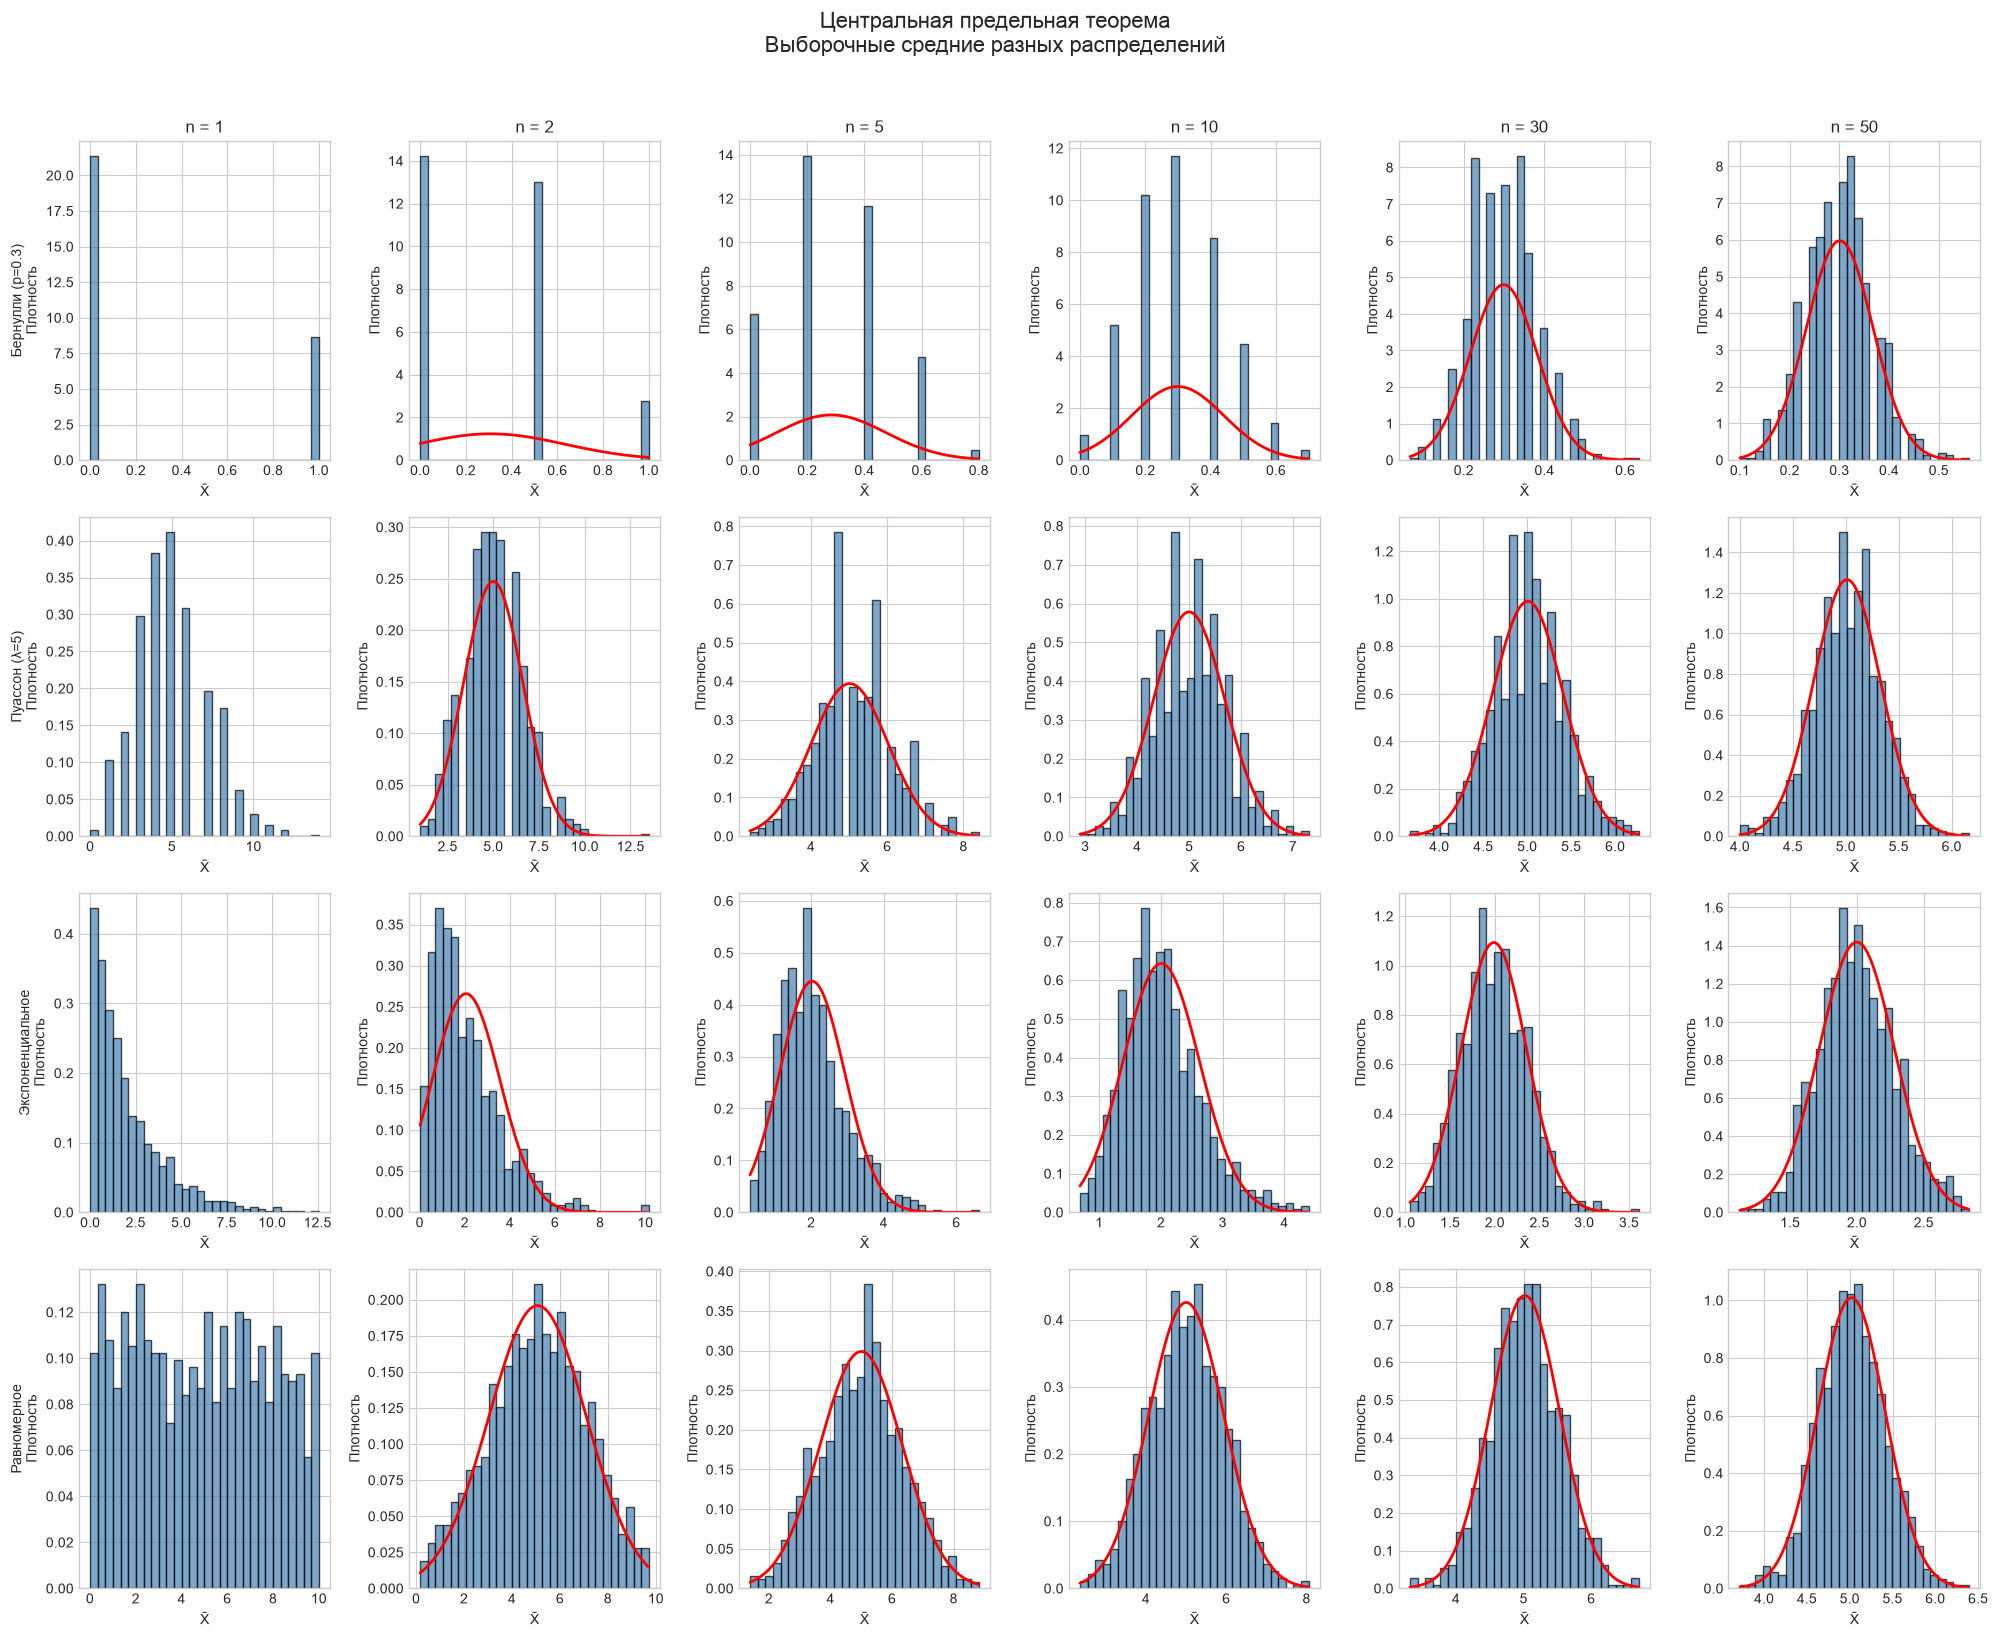

In [4]:
# Демонстрация ЦПТ на разных распределениях
np.random.seed(42)

# Параметры
n_samples = 1000  # Количество выборок
sample_sizes = [1, 2, 5, 10, 30, 50]  # Размеры выборок

# Разные распределения
distributions = {
    'Бернулли (p=0.3)': lambda size: np.random.binomial(1, 0.3, size),
    'Пуассон (λ=5)': lambda size: np.random.poisson(5, size),
    'Экспоненциальное': lambda size: np.random.exponential(2, size),
    'Равномерное': lambda size: np.random.uniform(0, 10, size)
}

fig, axes = plt.subplots(len(distributions), len(sample_sizes), 
                         figsize=(20, 16))

for dist_idx, (dist_name, dist_func) in enumerate(distributions.items()):
    for size_idx, n in enumerate(sample_sizes):
        # Генерация выборочных средних
        sample_means = []
        for _ in range(n_samples):
            sample = dist_func(n)
            sample_means.append(np.mean(sample))
        
        sample_means = np.array(sample_means)
        
        # Визуализация
        ax = axes[dist_idx, size_idx]
        ax.hist(sample_means, bins=30, density=True, alpha=0.7, 
                color='steelblue', edgecolor='black')
        
        # Добавить нормальную кривую
        if n > 1:
            x_range = np.linspace(sample_means.min(), sample_means.max(), 100)
            ax.plot(x_range, stats.norm.pdf(x_range, np.mean(sample_means), 
                                           np.std(sample_means)), 
                    'r-', linewidth=2)
        
        ax.set_xlabel('X̄')
        ax.set_ylabel('Плотность')
        
        if dist_idx == 0:
            ax.set_title(f'n = {n}')
        if size_idx == 0:
            ax.set_ylabel(f'{dist_name}\nПлотность')

plt.suptitle('Центральная предельная теорема\nВыборочные средние разных распределений', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

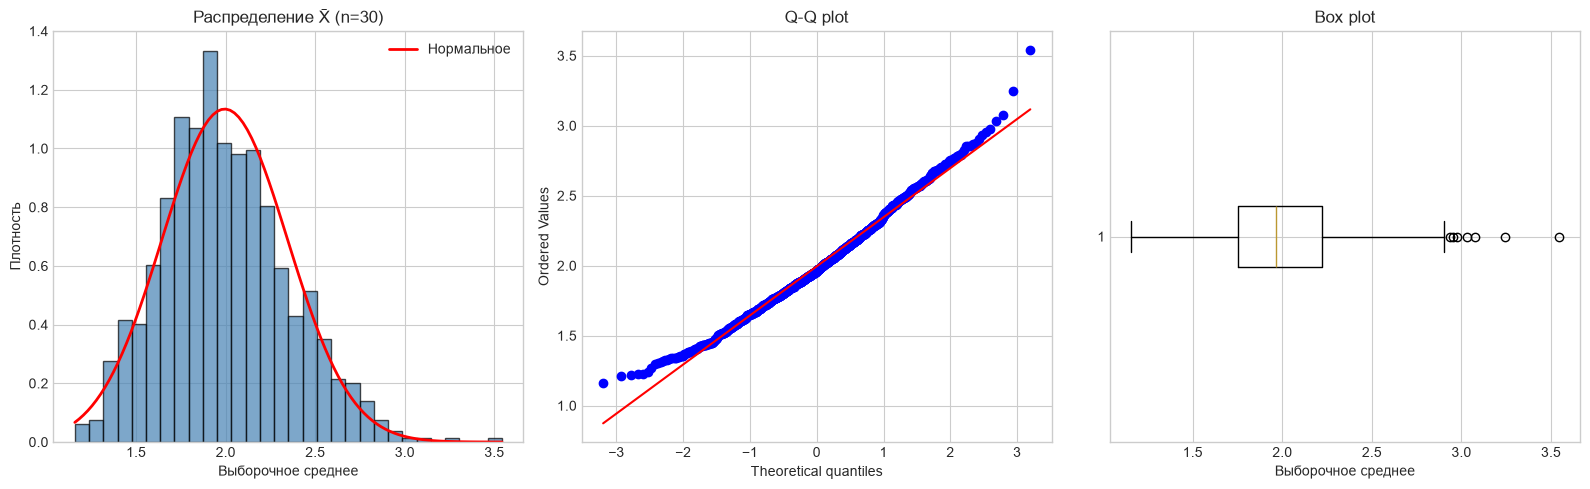

Тест Шапиро-Уилка на нормальность:
  Статистика: 0.9806
  p-значение: 0.1489
  Нормальное? Да (α=0.05)


In [5]:
# Проверка нормальности с помощью Q-Q plot
np.random.seed(42)

# Экспоненциальное распределение
n = 30
n_samples = 1000

sample_means = []
for _ in range(n_samples):
    sample = np.random.exponential(2, n)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Гистограмма
axes[0].hist(sample_means, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x_range = np.linspace(sample_means.min(), sample_means.max(), 100)
axes[0].plot(x_range, stats.norm.pdf(x_range, np.mean(sample_means), np.std(sample_means)), 
             'r-', linewidth=2, label='Нормальное')
axes[0].set_xlabel('Выборочное среднее')
axes[0].set_ylabel('Плотность')
axes[0].set_title(f'Распределение X̄ (n={n})')
axes[0].legend()

# Q-Q plot
stats.probplot(sample_means, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot')

# Box plot
axes[2].boxplot(sample_means, vert=False)
axes[2].set_xlabel('Выборочное среднее')
axes[2].set_title('Box plot')

plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка на нормальность
stat, p_value = stats.shapiro(sample_means[:100])  # Тест на подвыборке
print(f'Тест Шапиро-Уилка на нормальность:')
print(f'  Статистика: {stat:.4f}')
print(f'  p-значение: {p_value:.4f}')
print(f'  Нормальное? {"Да" if p_value > 0.05 else "Нет"} (α=0.05)')

## 4. Стандартная ошибка

**Стандартная ошибка** (Standard Error, SE) — это стандартное отклонение выборочного среднего.

$$SE = \frac{\sigma}{\sqrt{n}}$$

где:
- $\sigma$ — стандартное отклонение генеральной совокупности
- $n$ — размер выборки

**Интерпретация:** SE показывает, насколько в среднем выборочное среднее отклоняется от истинного среднего.

**Ключевые соотношения:**
- Увеличение $n$ в 4 раза уменьшает SE в 2 раза
- SE используется для построения доверительных интервалов
- SE определяет точность оценки среднего

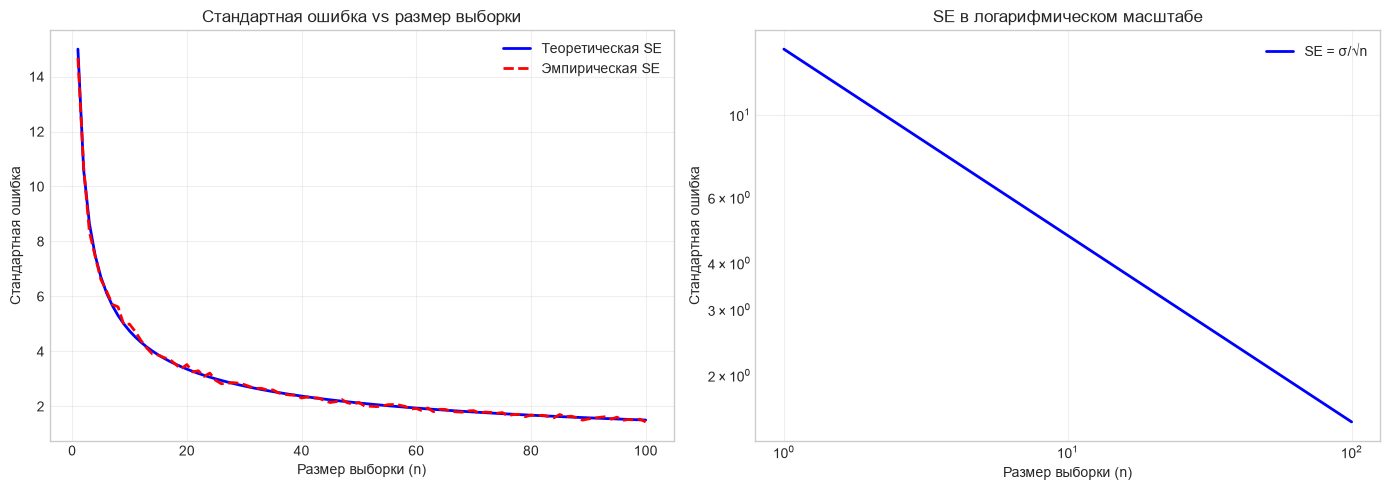

Стандартная ошибка для разных размеров выборки
σ = 15
n =   1: SE = 15.0000 (σ/√n = 15/√1)
n =  10: SE = 4.7434 (σ/√n = 15/√10)
n =  25: SE = 3.0000 (σ/√n = 15/√25)
n =  50: SE = 2.1213 (σ/√n = 15/√50)
n = 100: SE = 1.5000 (σ/√n = 15/√100)
n = 400: SE = 0.7500 (σ/√n = 15/√400)


In [6]:
# Демонстрация: Стандартная ошибка vs размер выборки
np.random.seed(42)

# Параметры генеральной совокупности
mu = 100
sigma = 15

# Размеры выборок
sample_sizes = np.arange(1, 101)
n_experiments = 1000

# Теоретическая SE
theoretical_se = sigma / np.sqrt(sample_sizes)

# Эмпирическая SE
empirical_se = []
for n in sample_sizes:
    means = []
    for _ in range(n_experiments):
        sample = np.random.normal(mu, sigma, n)
        means.append(np.mean(sample))
    empirical_se.append(np.std(means))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SE vs n
axes[0].plot(sample_sizes, theoretical_se, 'b-', linewidth=2, label='Теоретическая SE')
axes[0].plot(sample_sizes, empirical_se, 'r--', linewidth=2, label='Эмпирическая SE')
axes[0].set_xlabel('Размер выборки (n)')
axes[0].set_ylabel('Стандартная ошибка')
axes[0].set_title('Стандартная ошибка vs размер выборки')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Логарифмический масштаб
axes[1].plot(sample_sizes, theoretical_se, 'b-', linewidth=2, label='SE = σ/√n')
axes[1].set_xlabel('Размер выборки (n)')
axes[1].set_ylabel('Стандартная ошибка')
axes[1].set_title('SE в логарифмическом масштабе')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Примеры SE для разных n
print('Стандартная ошибка для разных размеров выборки')
print('=' * 50)
print(f'σ = {sigma}')
for n in [1, 10, 25, 50, 100, 400]:
    se = sigma / np.sqrt(n)
    print(f'n = {n:>3}: SE = {se:.4f} (σ/√n = {sigma}/√{n})')

## 5. Практическое применение: Оценка среднего

**Задача:** Оценить средний рост студентов университета.

**Подход:**
1. Извлечь случайную выборку из $n$ студентов
2. Вычислить выборочное среднее $\bar{X}$
3. Использовать ЦПТ для оценки точности

**Формула:**
$$\bar{X} \approx N\left(\mu, \frac{\sigma^2}{n}\right)$$

**Доверительный интервал (95%):**
$$\bar{X} \pm 1.96 \cdot \frac{\sigma}{\sqrt{n}}$$

Оценка среднего роста студентов
Истинное среднее (μ): 170 см

Выборка (n = 100):
  Выборочное среднее (X̄): 171.17 см
  Выборочное std (s): 10.71 см
  Стандартная ошибка (SE): 1.07 см

95% доверительный интервал:
  [169.07, 173.27] см
  Ширина: 4.20 см

Истинное μ попадает в ДИ? True


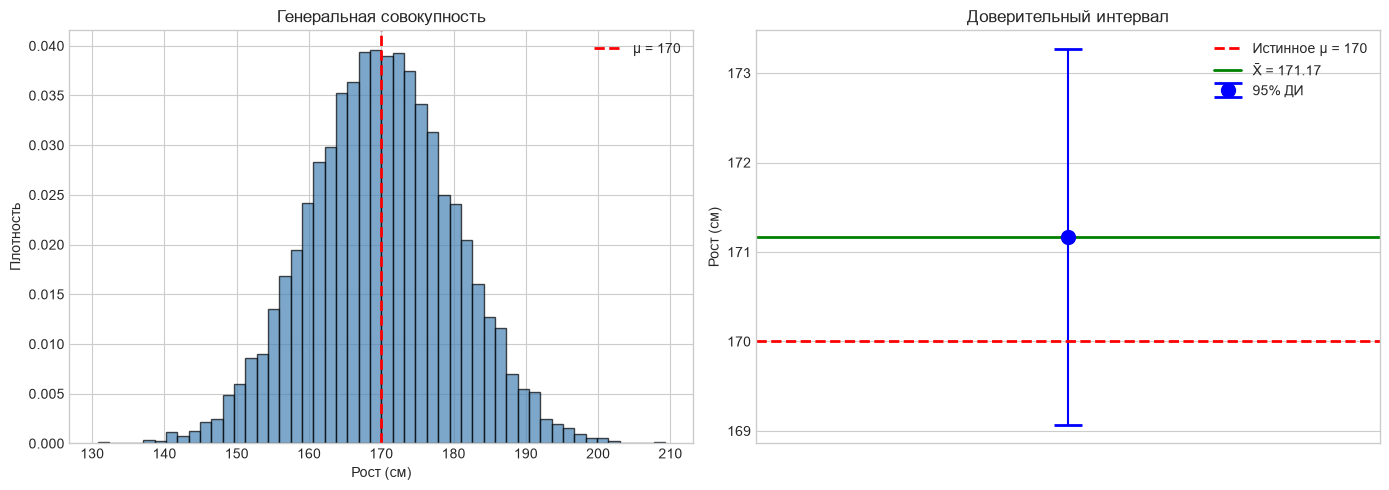

In [7]:
# Практический пример: Оценка среднего роста
np.random.seed(42)

# Генеральная совокупность (рост студентов)
population_mu = 170  # см
population_sigma = 10  # см
population_size = 10000

population = np.random.normal(population_mu, population_sigma, population_size)

# Извлечение выборки
sample_size = 100
sample = np.random.choice(population, size=sample_size, replace=False)

# Вычисление статистик
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
standard_error = sample_std / np.sqrt(sample_size)

# 95% доверительный интервал
z_score = 1.96  # Для 95% ДИ
ci_lower = sample_mean - z_score * standard_error
ci_upper = sample_mean + z_score * standard_error

print('Оценка среднего роста студентов')
print('=' * 60)
print(f'Истинное среднее (μ): {population_mu} см')
print(f'\nВыборка (n = {sample_size}):')
print(f'  Выборочное среднее (X̄): {sample_mean:.2f} см')
print(f'  Выборочное std (s): {sample_std:.2f} см')
print(f'  Стандартная ошибка (SE): {standard_error:.2f} см')
print(f'\n95% доверительный интервал:')
print(f'  [{ci_lower:.2f}, {ci_upper:.2f}] см')
print(f'  Ширина: {ci_upper - ci_lower:.2f} см')

# Проверка: попадает ли истинное среднее в ДИ?
print(f'\nИстинное μ попадает в ДИ? {ci_lower <= population_mu <= ci_upper}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение генеральной совокупности
axes[0].hist(population, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(population_mu, color='red', linestyle='--', linewidth=2, 
                label=f'μ = {population_mu}')
axes[0].set_xlabel('Рост (см)')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Генеральная совокупность')
axes[0].legend()

# Доверительный интервал
axes[1].errorbar(x=0, y=sample_mean, yerr=z_score * standard_error, 
                 fmt='o', markersize=10, capsize=10, capthick=2, color='blue',
                 label='95% ДИ')
axes[1].axhline(y=population_mu, color='red', linestyle='--', linewidth=2, 
                label=f'Истинное μ = {population_mu}')
axes[1].axhline(y=sample_mean, color='green', linestyle='-', linewidth=2, 
                label=f'X̄ = {sample_mean:.2f}')
axes[1].set_ylabel('Рост (см)')
axes[1].set_title('Доверительный интервал')
axes[1].legend()
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Закон больших чисел
Смоделируйте подбрасывание нечестной монеты (P(H) = 0.6) 10000 раз.
1. Постройте график кумулятивного среднего
2. При каком количестве бросков среднее стабилизируется?

### Упражнение 2: ЦПТ для разных распределений
Проверьте ЦПТ для:
1. Распределения Пуассона (λ = 3)
2. Равномерного распределения U(0, 10)
3. Экспоненциального распределения (λ = 0.5)

Для каждого распределения:
- Сгенерируйте 1000 выборок размера n = 30
- Постройте гистограмму выборочных средних
- Добавьте нормальную кривую

### Упражнение 3: Стандартная ошибка
Дано: σ = 20, необходимо оценить среднее с точностью ±2 (с вероятностью 95%).
1. Какой минимальный размер выборки нужен?
2. Постройте зависимость SE от n для n от 1 до 1000

### Упражнение 4: Доверительный интервал
Измерения температуры пациентов дали:
```
[36.6, 36.8, 37.0, 36.9, 37.1, 36.7, 37.2, 36.5, 37.3, 36.4]
```

1. Вычислите 95% доверительный интервал для средней температуры
2. Попадает ли нормальная температура (36.6°) в этот интервал?

---

**Решения** можно найти в ноутбуке `solutions/06_Solutions.ipynb`